# Automated Speech Recognition Project Python Code

This code is the python code for the Deep Learning module on automated speech recognition.

The code does the following:

*   Pulls the data in from github
*   Unzips the data
*   Creates Keras training and validation datasets
*   Extracts input-output data from the Keras datasets
*   Neural Network baseline model building
*   Neural Network optimisation:
1. grid search over number of layers and filters per layer
2. training speedup
3. improve generalisation by model generalisation
4. hyperparameter optimisation


In [ ]:
# NOTE: YOU SHOULD ONLY NEED TO RUN THIS STEP THE FIRST TIME IN A SESSION
import tensorflow as tf

# get the data from github and unzip
!wget https://raw.githubusercontent.com/andrsn/data/main/speechImageData.zip
!unzip -q /content/speechImageData.zip

# install scikeras
!python -m pip install scikeras

--2024-03-22 22:33:11--  https://raw.githubusercontent.com/andrsn/data/main/speechImageData.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9872924 (9.4M) [application/zip]
Saving to: ‘speechImageData.zip’

speechImageData.zip 100%[===================>]   9.42M  --.-KB/s    in 0.1s    

2024-03-22 22:33:11 (94.2 MB/s) - ‘speechImageData.zip’ saved [9872924/9872924]



## Pre-process data into training and validation sets, using Keras dataset objects

Note that when the data is unzipped it is stored locally to Google Colab in the content folder and the unzipped folder is called

'speechImageData - Copy'

and it contains:

the training data in the folder TrainData and

the validation in the folder ValData

There are 12 classes of different spoken words and the spectrograms, which form the input image data are of size 98x50 pixels.

In [4]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory='/content/speechImageData - Copy/TrainData',
    labels='inferred',
    color_mode="grayscale",
    label_mode='categorical',
    batch_size=128,
    image_size=(98, 50)
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory='/content/speechImageData - Copy/ValData',
    labels='inferred',
    color_mode="grayscale",
    label_mode='categorical',
    batch_size=128,
    image_size=(98, 50)
)

Found 2001 files belonging to 12 classes.
Found 1171 files belonging to 12 classes.


## Extract input-output data into arrays, which can be more useful

In [5]:
import numpy as np

# Extract the  training input images and output class labels
x_train = []
y_train = []
for images, labels in train_ds.take(-1):
    x_train.append(images.numpy())
    y_train.append(labels.numpy())

x_train = np.concatenate(x_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

print(y_train)


# Extract the validation input images and output class labels
x_val = []
y_val = []
for images, labels in val_ds.take(-1):
    x_val.append(images.numpy())
    y_val.append(labels.numpy())

x_val = np.concatenate(x_val, axis=0)
y_val = np.concatenate(y_val, axis=0)

print(y_val)



[[0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [4]:
print(x_train.shape) # check the shape of dataset x

(2001, 98, 50, 1)


# Baseline Model

Design of Deep Convolutional Network (Accuracy >= 60%)

To complete the Automated Speech Recognition project, the initial version of the deep convolutional network is designed based on the previous re-use baseline model. Taking the "at least one convolutional, batchnorm, maxpool and dropout layer" as the limitation, as well as considering the provided 'expert knowledge' of the final layer tip, a basic deep convolutional network is designed as:

Image input layer



Convolution 2D layer

Batch Normalisation layer

ReLU Activation layer

Max Pooling 2D layer

Max Pooling (time Pooling) layer

Dropout layer

Fully Connected layer

Softmax layer

 It is worth noting that the second max pooling layer acts as the final layer of feature extraction across the time-dimension, this final layer is expected to improve the performance of the deep convolutional network. The Adam algorithm (learning rate 0.01) is selected as the optimizer. The number of filters, the kernel_size of the convolutional layer, the pool_size, the strides of the max pooling layer is manually explored to obtain the required accuracy (>=60%). Compared to the previous image recognition dataset during lab section, this voice iamge input dataset is larger in size. Therefore, it is reasonable to set the kernel of convolutional layer larger, as well as the pool size and strides in the maxpooling layer. This will imporve the model's performance of recognising the voice feature. A dropout rate was selected as 0.4 to avoid overfitting and increase the validation accuracy.

With a little fluctuation (approx. +/- 5%), the validation accuracy is able to reach to 60% after 16 epochs. Both the training accuracy and the validation accuracy show an increasing trend. And the model loss of training and validation decreases from very large to relatively small.

The detailed implementation of the deep convolutional network is shown in the code as follows:

In [6]:
# import the libaries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Activation, Input, Conv2D, MaxPooling2D, Flatten, Softmax
from keras import optimizers, regularizers
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from scipy.stats import mode
from hyperopt import fmin, tpe, hp
from keras.datasets import mnist
from keras.utils import to_categorical

In [6]:
# print data info
print('Number of training data:' , len(y_train))
print('Number of testing data:' , len(y_val))

# define class labels
class_names = ['down', 'go', 'left', 'no', 'off', 'unknown'
               'on', 'right', 'stop', 'up', 'yes', 'background']
num_classes = 12 # number of classes

# number of convolutional filters
num_filters = 32 # 4, 10, 16, 32, 64 128 was explored, 32 is finally selected

timePoolSize = 12 # tuned for good performance (expert's knowledge)

# define model
model = Sequential()
# input layer
model.add(Input(shape=(98,50,1)))
# layers of one convolutional, batchnorm, maxpool and dropout
model.add(Conv2D(num_filters, kernel_size =(12, 12), padding='same'))#3,3
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size =(4, 4), strides=(4, 2), padding= 'same'))

# based on 'expert' knowledge, make improvement
model.add(MaxPooling2D(pool_size =(timePoolSize, 1), strides=(1, 1), padding = 'same'))
model.add(Dropout(0.4))
model.add(Flatten())

model.add(Dense(num_classes))
model.add(Softmax())

# set the optimization options and compile the model, learning_rate=0.01
opt = optimizers.Adam(learning_rate=0.01)
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

# print out the model summary
model.summary()


Number of training data: 2001
Number of testing data: 1171
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 50, 32)        4640      
                                                                 
 batch_normalization (Batch  (None, 98, 50, 32)        128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 98, 50, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 25, 25, 32)        0         
 D)                                                              
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 25, 25, 32)        0         
 g2D)                                                          

In [7]:
history = model.fit(x_train, y_train, batch_size=128, epochs=30, validation_split=0.1)

Epoch 1/30
15/15 [==============================] - 6s 55ms/step - loss: 221.4612 - accuracy: 0.1533 - val_loss: 963.2554 - val_accuracy: 0.1791
Epoch 2/30
15/15 [==============================] - 0s 26ms/step - loss: 74.8035 - accuracy: 0.2033 - val_loss: 184.5617 - val_accuracy: 0.1990
Epoch 3/30
15/15 [==============================] - 0s 26ms/step - loss: 30.2780 - accuracy: 0.2600 - val_loss: 47.4493 - val_accuracy: 0.3035
Epoch 4/30
15/15 [==============================] - 0s 26ms/step - loss: 11.2882 - accuracy: 0.3167 - val_loss: 24.5522 - val_accuracy: 0.3085
Epoch 5/30
15/15 [==============================] - 0s 25ms/step - loss: 6.1047 - accuracy: 0.3717 - val_loss: 11.3337 - val_accuracy: 0.3333
Epoch 6/30
15/15 [==============================] - 0s 26ms/step - loss: 4.0902 - accuracy: 0.3933 - val_loss: 7.0934 - val_accuracy: 0.2786
Epoch 7/30
15/15 [==============================] - 0s 26ms/step - loss: 2.8852 - accuracy: 0.4522 - val_loss: 6.5261 - val_accuracy: 0.3831
E

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


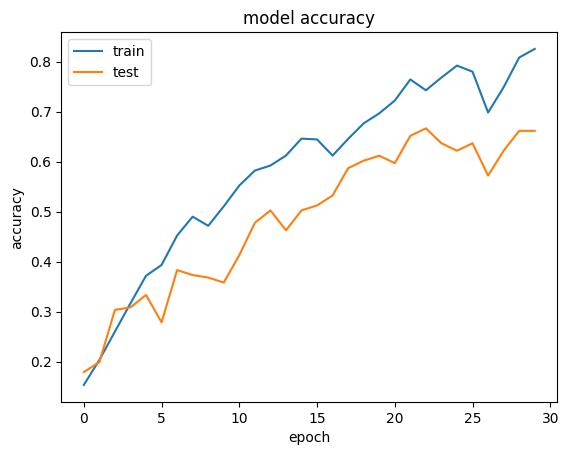

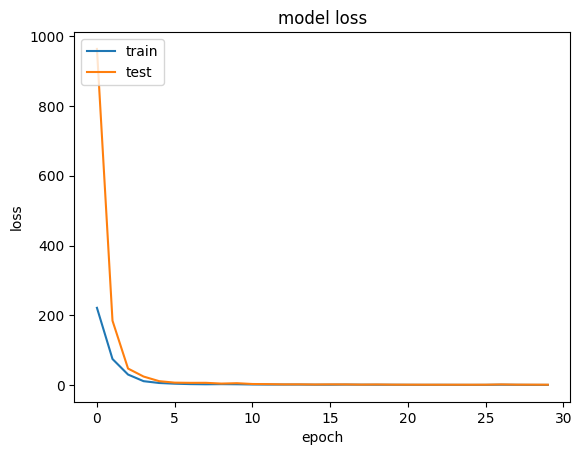

In [8]:
# list all data in history
print(history.history.keys())

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


Print out the accuracy on the independent validation dataset

In [9]:
# print out the accuracy on independent test data
score = model.evaluate(x_val, y_val, verbose=0)
print("Test accuracy:", score[1])

Test accuracy: 0.5670367479324341


Calculate and display the confusion matrix to have more detailed insight into classifier performance across all classes than simply inspecting the overall accuracy.

37/37 [==============================] - 0s 3ms/step


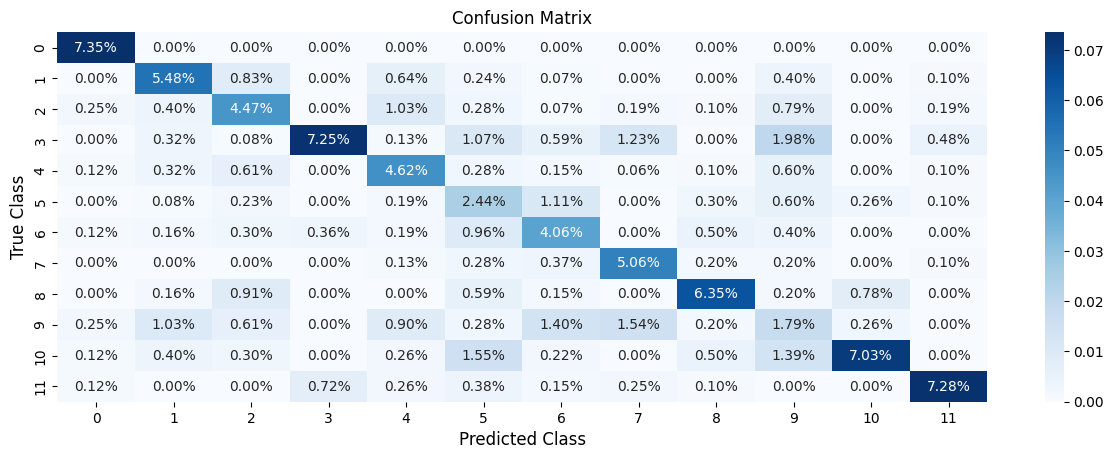

In [10]:
# obtain model predictions and convert softmax outputs 0-1 to integer class label predictions
Yhat = model.predict(x_val) # predict model outputs on validation data as softmax outputs of probability of each class
Yhat_integer = np.argmax(Yhat, axis=1) # obtain the most likely class prediction as the argument of the max softmax output
Y_test_integer = np.argmax(y_val, axis=1) # obtain the true class as an integer

# calculate and plot confusion matrix
cm = confusion_matrix(Y_test_integer, Yhat_integer , normalize="pred") # calculate the confusion matrix
plt.figure(2).set_figwidth(15)                       # setup new figure
sns.heatmap(cm/np.sum(cm), annot=True, fmt=".2%", cmap="Blues",)    # plot the confusion matrix using the sns package
plt.title("Confusion Matrix", fontsize = 12)             # title
plt.xlabel("Predicted Class", fontsize = 12)             # xlabel
plt.ylabel("True Class", fontsize = 12)               # ylabel
plt.show()                              # show plot

From the confusion matrix, it can be concluded that the designed model has a normal performance on the validation dataset. The model is able to make some right recognition of the input voice. However, the recognition accuracy is not yet satisfied in some classes (1, 2, 3, 5, 9, 10). This model needs to be further optimized.

# Grid Search + Successive Halving

Grid Search of 3x3 grid + speed ups using HalvingGridSearchCV

Here a repeated code scructure is reused because the 'create_model' process needs to be defined separately as a function (a little change involved). This function will be called in the later section.

In [16]:
# print data info
print('Number of training data:' , len(y_train))
print('Number of testing data:' , len(y_val))

# define class labels
class_names = ['down', 'go', 'left', 'no', 'off', 'unknown'
        'on', 'right', 'stop', 'up', 'yes', 'background']
print(len(class_names))

timePoolSize = 12 # tuned for good performance here

# function to build the model
# select number of layers and number of filters per layer as the hyperparameters
def create_model(num_layers, num_filters):
  # define model
  model = Sequential()

  model.add(Input(shape=(98,50,1)))
  # layers of at least one convolutional, batchnorm, maxpool and dropout
  model.add(Conv2D(num_filters, kernel_size =(12, 12), padding='same'))
  model.add(BatchNormalization())
  model.add(Activation('relu'))

  # hidden layers controled by the hyperparameter 'num_layers'
  for i in range(num_layers-1):
    model.add(Conv2D(num_filters, kernel_size =(12, 12), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size =(4, 4), strides=(4, 2), padding= 'same'))

  # based on 'expert' knowledge, make improvement
  model.add(MaxPooling2D(pool_size =(timePoolSize, 1), strides=(1, 1), padding = 'same'))
  model.add(Dropout(0.4))
  model.add(Flatten())

  model.add(Dense(num_classes))
  model.add(Softmax())

  # set the optimization options and compile the model, learning_rate=0.001
  # the loss function need to be changed to tf.keras.losses.CategoricalCrossentropy()
  opt = optimizers.Adam(learning_rate=0.01)
  model.compile(loss=tf.keras.losses.CategoricalCrossentropy(), optimizer=opt, metrics=["accuracy"]) #categorical_crossentropy sparse_categorial_crossentropy SparseCategoricalCrossentropy
  return model

# build the model as a classifier
model= KerasClassifier(model=create_model, epochs=4, batch_size=128, verbose=1, num_layers=[2, 3, 4], num_filters=[16, 32 ,64])#, num_layers=2, num_filters=16)

# define the parameter grid 3x3
param_grid = {'num_layers':[2, 3, 4],
        'num_filters': [16, 32, 64]}


Number of training data: 2001
Number of testing data: 1171
11


In [15]:
# Perform Grid Search over number of layers and filters per layer (3x3) grid
grid = GridSearchCV(estimator=model,param_grid=param_grid, n_jobs=-1, verbose=1, cv=3)
grid_result = grid.fit(x_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


KeyboardInterrupt: 

In [ ]:
# display the general result
[grid_result.best_score_,grid_result.best_params_]

[0.6006996501749126, {'num_filters': 16, 'num_layers': 3}]

In [ ]:
# analyse output
print(grid_result.best_params_) # display the best parameters
df = pd.DataFrame(grid_result.cv_results_) # create the dataframe
print(df) # display the dataframe of results

{'num_filters': 16, 'num_layers': 3}
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0      12.941446      1.950266         0.737800        0.168945   
1      11.964637      0.204896         0.461271        0.075826   
2      12.288796      0.547666         0.670892        0.152479   
3      15.971758      4.290868         0.723623        0.125724   
4      18.563038      6.073955         0.845605        0.509863   
5      20.680799      2.418356         0.949521        0.570979   
6      30.775071      8.671533         1.807522        0.786707   
7      38.620140      6.112607         1.298977        0.404849   
8      35.752234     10.559781         1.120433        0.288896   

  param_num_filters param_num_layers                                params  \
0                16                2  {'num_filters': 16, 'num_layers': 2}   
1                16                3  {'num_filters': 16, 'num_layers': 3}   
2                16                4  {'num_filters': 16, 

As demonstrated in the printed results, the candidate 1 ({'num_filters': 16, 'num_layers': 3} ) and candidate 8 ({'num_filters': 64, 'num_layers': 4}) have the highest mean test score 0.6007, which indicates that these two groups are potentially the best hyperparameter combinations in the designed grid. However, the more hidden layers and filters per layer, the more complicated the CNN is. The training time will be longer and make the training progress less efficient. the candidate 1 has less fit and score time. Therefore, the group 1 is the best combination since it has relative smaller number of layers and filters.

Successive Halving

In [17]:
# for Successive Halving approach, some changes need to be done.
# re-define the function of building the model, change the loss function to sparse categorical crossentropy

# print data info
print('Number of training data:' , len(y_train))
print('Number of testing data:' , len(y_val))

# define class labels
class_names = ['down', 'go', 'left', 'no', 'off', 'unknown'
               'on', 'right', 'stop', 'up', 'yes', 'background']
print(len(class_names))

timePoolSize = 12 # tuned for good performance here

# function to build the model
def create_model(num_layers, num_filters):
  # define model
  model = Sequential()

  model.add(Input(shape=(98,50,1)))

  model.add(Conv2D(num_filters, kernel_size =(12, 12), padding='same'))
  model.add(BatchNormalization())
  model.add(Activation('relu'))

  for i in range(num_layers-1):
    model.add(Conv2D(num_filters, kernel_size =(12, 12), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size =(4, 4), strides=(4, 2), padding= 'same'))

  model.add(MaxPooling2D(pool_size =(timePoolSize, 1), strides=(1, 1), padding = 'same'))
  model.add(Dropout(0.4))
  model.add(Flatten())

  model.add(Dense(num_classes))
  model.add(Softmax())

  # set the optimization options and compile the model, learning_rate=0.001
  opt = optimizers.Adam(learning_rate=0.01)
  # change the loss function to SparseCategoricalCrossentropy() for the successive halving approach
  model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer=opt, metrics=["accuracy"])
  return model

model= KerasClassifier(model=create_model, epochs=4, batch_size=8, verbose=1, num_layers=[2, 3, 4], num_filters=[16, 32 ,64])

param_grid = {'num_layers':[2, 3, 4],
        'num_filters': [16, 32, 64]}

grid = HalvingGridSearchCV(estimator=model,param_grid=param_grid, n_jobs=-1, verbose=1, cv=3,factor=3)
grid_result = grid.fit(x_train, y_train.argmax(axis=1))
[grid_result.best_score_,grid_result.best_params_]

Number of training data: 2001
Number of testing data: 1171
11
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 222
max_resources_: 2001
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 9
n_resources: 222
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------
iter: 1
n_candidates: 3
n_resources: 666
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------
iter: 2
n_candidates: 1
n_resources: 1998
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Epoch 1/4
251/251 [==============================] - 12s 30ms/step - loss: 7.4170 - accuracy: 0.2709
Epoch 2/4
251/251 [==============================] - 7s 27ms/step - loss: 1.3757 - accuracy: 0.5627
Epoch 3/4
251/251 [==============================] - 7s 27ms/step - loss: 1.0657 - accuracy: 0.6562
Epoch 4/4
251/251 [==============================] - 7s 27ms/step - loss: 0.9656 - accuracy: 0.6982


[0.5465465465465466, {'num_filters': 64, 'num_layers': 3}]

Comparing to the Grid Search approach, the same result is obtained using Successive Halving but requiring less computational time. It can be observed that the speed up approach "Successive Halving" accelerate the Grid Search process as it will terminate poor models early and continue with the good ones until getting the results. The detailed computational time can be investigated via the 'tic' function. Therefore, this approach improves the computational efficiency of hyperparameter optimization.

In [ ]:
# for Successive Halving approach, some changes need to be done.
# re-define the function of building the model, change the loss function to sparse categorical crossentropy

# print data info
print('Number of training data:' , len(y_train))
print('Number of testing data:' , len(y_val))

# define class labels
class_names = ['down', 'go', 'left', 'no', 'off', 'unknown'
               'on', 'right', 'stop', 'up', 'yes', 'background']
print(len(class_names))
num_classes = 12 # number of classes

timePoolSize = 12 # tuned for good performance here

# function to build the model
def create_model(num_layers, num_filters):
  # define model
  model = Sequential()

  model.add(Input(shape=(98,50,1)))

  model.add(Conv2D(num_filters, kernel_size =(12, 12), padding='same'))
  model.add(BatchNormalization())
  model.add(Activation('relu'))

  for i in range(num_layers-1):
    model.add(Conv2D(num_filters, kernel_size =(12, 12), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size =(4, 4), strides=(4, 2), padding= 'same'))

  model.add(MaxPooling2D(pool_size =(timePoolSize, 1), strides=(1, 1), padding = 'same'))
  model.add(Dropout(0.4))
  model.add(Flatten())

  model.add(Dense(num_classes))
  model.add(Softmax())

  # set the optimization options and compile the model, learning_rate=0.001
  opt = optimizers.Adam(learning_rate=0.01)
  # change the loss function to SparseCategoricalCrossentropy() for the successive halving approach
  model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer=opt, metrics=["accuracy"])
  return model

model= KerasClassifier(model=create_model, epochs=4, batch_size=8, verbose=1, num_layers=[2, 3, 4], num_filters=[16, 32 ,64])

param_grid = {'num_layers':[2, 3, 4],
        'num_filters': [16, 32, 64]}

# Perform successive halving in the Grid Search over number of layers and filters per layer (3x3) grid
grid = HalvingGridSearchCV(estimator=model,param_grid=param_grid, n_jobs=-1, verbose=1, cv=3,factor=3)
grid_result = grid.fit(x_train, y_train.argmax(axis=1))
[grid_result.best_score_,grid_result.best_params_]

Number of training data: 2001
Number of testing data: 1171
11
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 222
max_resources_: 2001
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 9
n_resources: 222
Fitting 3 folds for each of 9 candidates, totalling 27 fits


KeyboardInterrupt: 

In [ ]:
# re-define function to build the model change the loss function to sparse categorical crossentropy
# select number of layers and number of filters per layer as the hyperparameters
def create_model(num_layers, num_filters):
  # define model
  model = Sequential()

  model.add(Input(shape=(98,50,1)))
  # layers of at least one convolutional, batchnorm, maxpool and dropout
  model.add(Conv2D(num_filters, kernel_size =(12, 12), padding='same'))
  model.add(BatchNormalization())
  model.add(Activation('relu'))

  # hidden layers controled by the hyperparameter 'num_layers'
  for i in range(num_layers-1):
    model.add(Conv2D(num_filters, kernel_size =(12, 12), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size =(4, 4), strides=(4, 2), padding= 'same'))

  # based on 'expert' knowledge, make improvement
  model.add(MaxPooling2D(pool_size =(timePoolSize, 1), strides=(1, 1), padding = 'same'))
  model.add(Dropout(0.4))
  model.add(Flatten())

  model.add(Dense(num_classes))
  model.add(Softmax())

  # set the optimization options and compile the model, learning_rate=0.001
  # the loss function need to be changed to tf.keras.losses.CategoricalCrossentropy()
  opt = optimizers.Adam(learning_rate=0.01)
  model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer=opt, metrics=["accuracy"]) #categorical_crossentropy sparse_categorial_crossentropy SparseCategoricalCrossentropy
  return model

# build the model as a classifier
model= KerasClassifier(model=create_model, epochs=4, batch_size=128, verbose=1, num_layers=[2, 3, 4], num_filters=[16, 32 ,64])

In [ ]:
# Perform successive halving in the Grid Search over number of layers and filters per layer (3x3) grid

halving_grid = HalvingGridSearchCV(estimator=model,param_grid=param_grid, n_jobs=-1, verbose=1, cv=3,factor=3)
halving_grid_result = halving_grid.fit(x_train, y_train.argmax(axis=1))

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 222
max_resources_: 2001
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 9
n_resources: 222
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# analyse output
print(halving_grid_result.best_params_) # display the best parameters
df = pd.DataFrame(halving_grid_result.cv_results_) # create the dataframe
print(df) # display the dataframe of results

{'num_filters': 16, 'num_layers': 3}
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0      12.941446      1.950266         0.737800        0.168945   
1      11.964637      0.204896         0.461271        0.075826   
2      12.288796      0.547666         0.670892        0.152479   
3      15.971758      4.290868         0.723623        0.125724   
4      18.563038      6.073955         0.845605        0.509863   
5      20.680799      2.418356         0.949521        0.570979   
6      30.775071      8.671533         1.807522        0.786707   
7      38.620140      6.112607         1.298977        0.404849   
8      35.752234     10.559781         1.120433        0.288896   

  param_num_filters param_num_layers                                params  \
0                16                2  {'num_filters': 16, 'num_layers': 2}   
1                16                3  {'num_filters': 16, 'num_layers': 3}   
2                16                4  {'num_filters': 16, 

In [ ]:


halving_grid = HalvingGridSearchCV(estimator=model,param_grid=param_grid, n_jobs=-1, verbose=1, cv=3,factor=3)#, n_jobs=-1, cv=3) , resource='n_estimators', max_resources=30
halving_grid_result = halving_grid.fit(x_train, y_train.argmax(axis=1))#, batch_size=8, epochs=30, validation_split=0.1) y_train.argmax(axis=1)

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 222
max_resources_: 2001
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 9
n_resources: 222
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------
iter: 1
n_candidates: 3
n_resources: 666
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------
iter: 2
n_candidates: 1
n_resources: 1998
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Epoch 1/4
251/251 [==============================] - 4s 10ms/step - loss: 13.0631 - accuracy: 0.2879
Epoch 2/4
251/251 [==============================] - 3s 10ms/step - loss: 1.6759 - accuracy: 0.4868
Epoch 3/4
251/251 [==============================] - 2s 10ms/step - loss: 1.3643 - accuracy: 0.5932
Epoch 4/4
251/251 [==============================] - 2s 9ms/step - loss: 1.1615 - accuracy: 0.6287


In [ ]:
# Perform successive halving in the Grid Search over number of layers and filters per layer (3x3) grid
grid = HalvingGridSearchCV(estimator=model,param_grid=param_grid, n_jobs=-1, verbose=1, cv=3,factor=3)
grid_result = grid.fit(x_train, y_train.argmax(axis=1))

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 222
max_resources_: 2001
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 9
n_resources: 222
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------
iter: 1
n_candidates: 3
n_resources: 666
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------
iter: 2
n_candidates: 1
n_resources: 1998
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Epoch 1/4
251/251 [==============================] - 5s 7ms/step - loss: 3.1242 - accuracy: 0.2929
Epoch 2/4
251/251 [==============================] - 2s 8ms/step - loss: 1.4688 - accuracy: 0.5157
Epoch 3/4
251/251 [==============================] - 2s 7ms/step - loss: 1.1194 - accuracy: 0.6347
Epoch 4/4
251/251 [==============================] - 2s 8ms/step - loss: 1.0287 - accuracy: 0.6567


# Model Averaging with 5 Models

The general idea of model averaging is to sample the dataset with replacement and train 5 models on the sampled dataset. Then, obtain the prediction of each model and vote for a majority prediction. Evaluate the accuracy of the voted prediction and compare to the baseline model to check if it has a better accuracy.

In [ ]:
# Sampling the dataset to x1 and y1
import random

nsamples = 2001

data_index = list(range(1,nsamples))
idx = random.choices(data_index, k=nsamples)
x1 = np.zeros([nsamples,98,50,1])
y1 = np.zeros([nsamples,12])

for i in range(nsamples):
  x1[i] = x_train[idx[i],:,:,:]
  y1[i] = y_train[idx[i],:]

# print(x1)
print(y1)
print(idx)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[1809, 1787, 1098, 404, 1675, 1247, 1276, 1404, 534, 220, 1989, 730, 362, 25, 300, 1548, 114, 985, 941, 1400, 1696, 14, 796, 512, 104, 984, 628, 1353, 1998, 1989, 297, 1373, 1624, 725, 456, 202, 1036, 87, 173, 1123, 935, 1444, 33, 1326, 862, 888, 1738, 1468, 1177, 1521, 897, 1235, 1031, 1490, 1051, 613, 1581, 907, 1679, 1796, 564, 1622, 370, 718, 682, 1628, 861, 1768, 1200, 478, 1125, 543, 868, 1057, 707, 564, 288, 717, 1252, 852, 453, 1946, 1098, 403, 1347, 1704, 452, 81, 1580, 1753, 421, 1928, 323, 161, 402, 352, 175, 134, 412, 453, 949, 1495, 489, 20, 577, 309, 1075, 1983, 1286, 1944, 1845, 1875, 1912, 677, 537, 455, 393, 756, 595, 1259, 308, 1069, 1896, 1778, 328, 888, 616, 484, 1581, 1629, 88, 1486, 552, 1698, 426, 1717, 106, 1022, 399, 1273, 293, 807, 414, 1015, 1197, 1580, 1277, 36, 1932, 1858, 1974, 572, 245, 1610, 1603, 561

In [ ]:
# redo the sampling for model 2, 3, 4, 5
idx = random.choices(data_index, k=nsamples)
x2 = np.zeros([nsamples,98,50,1])
y2 = np.zeros([nsamples,12])

for i in range(nsamples):
  x2[i] = x_train[idx[i],:,:,:]
  y2[i] = y_train[idx[i],:]

idx = random.choices(data_index, k=nsamples)
x3 = np.zeros([nsamples,98,50,1])
y3 = np.zeros([nsamples,12])

for i in range(nsamples):
  x3[i] = x_train[idx[i],:,:,:]
  y3[i] = y_train[idx[i],:]

idx = random.choices(data_index, k=nsamples)
x4 = np.zeros([nsamples,98,50,1])
y4 = np.zeros([nsamples,12])

for i in range(nsamples):
  x4[i] = x_train[idx[i],:,:,:]
  y4[i] = y_train[idx[i],:]

idx = random.choices(data_index, k=nsamples)
x5 = np.zeros([nsamples,98,50,1])
y5 = np.zeros([nsamples,12])

for i in range(nsamples):
  x5[i] = x_train[idx[i],:,:,:]
  y5[i] = y_train[idx[i],:]

In [ ]:
# Create 5 models
model1 = create_model(3,16)
model2 = create_model(3,16)
model3 = create_model(3,16)
model4 = create_model(3,16)
model5 = create_model(3,16)

In [ ]:
# train 5 models
print("model1:")
history1 = model1.fit(x1, y1, batch_size=128, epochs=10, validation_split=0.1)
print("model2:")
history2 = model2.fit(x2, y2, batch_size=128, epochs=10, validation_split=0.1)
print("model3:")
history3 = model3.fit(x3, y3, batch_size=128, epochs=10, validation_split=0.1)
print("model4:")
history4 = model4.fit(x4, y4, batch_size=128, epochs=10, validation_split=0.1)
print("model5:")
history5 = model5.fit(x5, y5, batch_size=128, epochs=10, validation_split=0.1)

model1:
Epoch 1/10
225/225 [==============================] - 4s 8ms/step - loss: 3.2087 - accuracy: 0.2761 - val_loss: 2.0931 - val_accuracy: 0.3881
Epoch 2/10
225/225 [==============================] - 2s 7ms/step - loss: 1.4302 - accuracy: 0.5383 - val_loss: 1.1524 - val_accuracy: 0.6368
Epoch 3/10
225/225 [==============================] - 2s 8ms/step - loss: 1.0364 - accuracy: 0.6600 - val_loss: 0.9034 - val_accuracy: 0.7413
Epoch 4/10
225/225 [==============================] - 2s 8ms/step - loss: 0.8643 - accuracy: 0.7039 - val_loss: 1.0303 - val_accuracy: 0.6816
Epoch 5/10
225/225 [==============================] - 2s 7ms/step - loss: 0.7621 - accuracy: 0.7539 - val_loss: 1.1038 - val_accuracy: 0.7313
Epoch 6/10
225/225 [==============================] - 1s 7ms/step - loss: 0.6980 - accuracy: 0.7850 - val_loss: 1.0027 - val_accuracy: 0.8010
Epoch 7/10
225/225 [==============================] - 2s 7ms/step - loss: 0.6262 - accuracy: 0.8011 - val_loss: 0.7536 - val_accuracy: 0.746

In [ ]:
# Get predictions for the test set and print the predictions
prediction_1 = model1.predict(x_val)
print("Predictions:", prediction_1)

prediction_2 = model2.predict(x_val)
print("Predictions:", prediction_2)

prediction_3 = model3.predict(x_val)
print("Predictions:", prediction_3)

prediction_4 = model4.predict(x_val)
print("Predictions:", prediction_4)

prediction_5 = model5.predict(x_val)
print("Predictions:", prediction_5)

37/37 [==============================] - 33s 900ms/step
Predictions: [[8.12070072e-01 7.16489321e-03 1.20675238e-02 ... 3.04227285e-02
  1.30735645e-02 1.27489641e-02]
 [4.80558313e-08 8.38599856e-09 4.29879037e-05 ... 9.89054143e-03
  5.55302715e-04 2.59689273e-07]
 [2.27309087e-07 2.84291178e-01 4.36467022e-01 ... 4.19422314e-02
  5.12039696e-04 9.58599529e-08]
 ...
 [9.85081451e-17 7.15985227e-09 5.55290036e-08 ... 1.57356135e-05
  8.38751106e-13 3.30092534e-13]
 [8.95373944e-08 6.05526147e-04 3.93213898e-01 ... 2.63446551e-02
  2.45597720e-01 2.90429603e-06]
 [6.09420880e-04 7.39112310e-03 3.94669041e-04 ... 7.29232794e-03
  1.89303160e-02 1.77784514e-05]]
37/37 [==============================] - 21s 568ms/step
Predictions: [[9.0837395e-01 4.3366649e-03 4.6945629e-03 ... 1.6132383e-02
  2.4177913e-02 3.7961898e-03]
 [3.8977625e-04 4.4205211e-04 8.8696675e-03 ... 1.2711320e-03
  1.7951158e-01 9.7948156e-05]
 [5.4408423e-07 4.0767950e-01 3.9141335e-02 ... 1.2625984e-03
  2.4854785e-0

In [ ]:
# obtain the most likely class prediction as the argument of the max softmax output
Yhat_1_integer = np.argmax(prediction_1, axis=1)
Yhat_2_integer = np.argmax(prediction_2, axis=1)
Yhat_3_integer = np.argmax(prediction_3, axis=1)
Yhat_4_integer = np.argmax(prediction_4, axis=1)
Yhat_5_integer = np.argmax(prediction_5, axis=1)

In [ ]:
# gather the predictions of 5 models together and display the result
predictions = np.vstack((Yhat_1_integer, Yhat_2_integer, Yhat_3_integer, Yhat_4_integer, Yhat_5_integer))
print(predictions)

[[ 0  3  2 ...  7  2  3]
 [ 0  3  6 ...  7  5  3]
 [ 0 11  8 ...  7 11  5]
 [ 0  3  1 ...  7  7  3]
 [ 0  3  8 ...  7  7  2]]


In [ ]:
# voting the majority class prediction using the 'mode' function
majority_prediction = mode(predictions, axis=0).mode # axis = 0 for column coomparison
print(majority_prediction)

[0 3 8 ... 7 7 3]


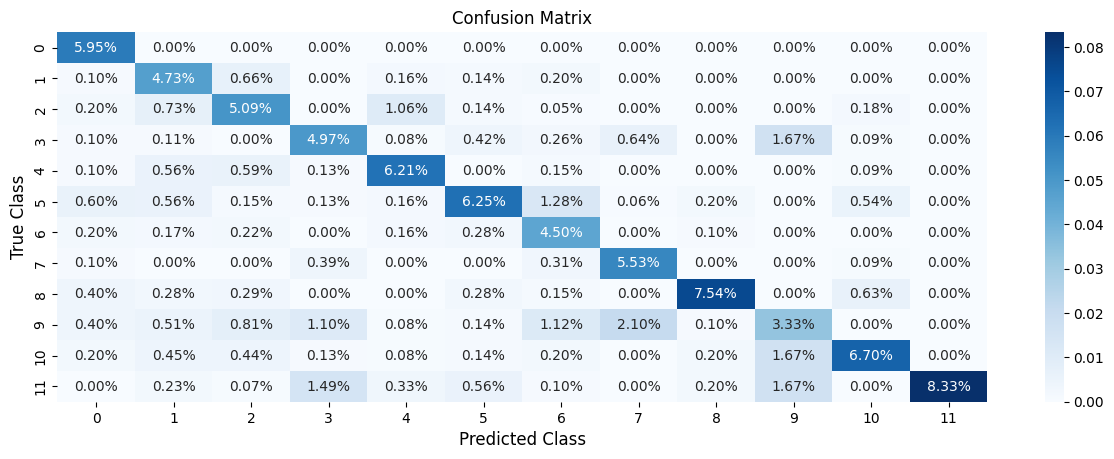

In [ ]:
# calculate and plot confusion matrix
cm = confusion_matrix(Y_test_integer, majority_prediction , normalize="pred")    # calculate the confusion matrix
plt.figure(2).set_figwidth(15)                              # setup new figure
sns.heatmap(cm/np.sum(cm), annot=True, fmt=".2%", cmap="Blues",)  # plot the confusion matrix using the sns package
plt.title("Confusion Matrix", fontsize = 12)            # title
plt.xlabel("Predicted Class", fontsize = 12)            # xlabel
plt.ylabel("True Class", fontsize = 12)              # ylabel
plt.show()                             # show plot

It can be concluded that after the implementation of hyperparameter optimization and model averaging, the model's performance is improved. Comparing to the single baseline model, the accuracy is much more better in all 12 classes. However, for the optimized model, some classes like the class 6 and class 9 are still difficult to make the right prediction. More advanced optimization approaches should be implemented to increase the accuracy. It is worth noting that that for the confusion matrix, all the 12 classes are equally split, so the max accuracy per class is 8.33%. The class 11 (word: background) reached to the max accuracy. The reason behind can be that class 11 has the largest number of data in the training dataset while smallest number in the validation dataset. The large amount of training data enhances the ability of making the right prediction. And the small amount of data in the validation dataset decreases the possibility of making mistakes. Therefore, the accuracy of class 11 is very high. Increasing the size of training data for tricky classes like class 9, class 6, class 1 can potentially increase the prediction accuracy.

# Bayesian Optimization for Hyperparameter Selection

Use Bayesian Optimization to explore the number of layers and filters per layer.

Firstly, model the objective function with available input dataset, then, choose the next update to maximise an acquisition function (optimizing).

In [ ]:
# load the MNIST dataset and process it
(x_train, y_train), (x_val, y_val) = mnist.load_data()
print(x_train.shape) #(60000, 28, 28)
x_train = x_train.reshape(-1,98,8,1).astype('float32') / 255.0
x_val = x_val.reshape(-1,98,8,1).astype('float32') / 255.0
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)

# define the search space for hyperparameters
space = {'num_hidden_layers': hp.choice('num_hidden_layers', [1, 2, 3]),
         'num_hidden_units': hp.choice('num_hiden_units', [16, 32, 64]),}
timePoolSize = 12 # tuned for good performance (expert's knowledge)
# define the objective function to minimize
def objective(params):
  # build the karas model with the given hyperparameters
  model = Sequential()

  model.add(Input(shape=(98,8,1))) # (98,50,1) (784,98,50)

  model.add(Conv2D(params['num_hidden_units'], kernel_size =(3, 3), padding='same'))
  model.add(BatchNormalization())
  model.add(Activation('relu'))

#
  # model.add(Input(shape=(784,))) # (98,50,1)

  # model.add(Conv2D(params['num_hidden_units'], kernel_size =(3, 3), padding='same'))
  # model.add(BatchNormalization())
  # model.add(Activation('relu'))
#

  for i in range(params['num_hidden_layers']-1):
    model.add(Conv2D(params['num_hidden_units'], kernel_size =(3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    # model.add(MaxPooling2D(pool_size =(2, 2)))#, strides=(4, 2), padding= 'same'))
    model.add(MaxPooling2D(pool_size =(2, 2), strides=(4, 2), padding= 'same'))

  # model.add(Conv2D(num_filters, kernel_size =(3, 3), padding='same'))
  # model.add(BatchNormalization())
  # model.add(Activation('relu'))

  model.add(MaxPooling2D(pool_size =(timePoolSize, 1), strides=(1, 1), padding = 'same'))
  model.add(Dropout(0.4))#$0.25, 0.5 0.4
  model.add(Flatten())

  #model.add(Dropout(0.25))

  model.add(Dense(params['num_hidden_units']))
  model.add(Softmax())

  # set the optimization options and compile the model, learning_rate=0.001
  opt = optimizers.Adam(learning_rate=0.01) #0.001, 0.01
  model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer=opt, metrics=["accuracy"])

  # train the model and evaluate on the test set
  model.fit(x_train, y_train, epochs = 5, batch_size=32,verbose=0)
  loss, accuracy = model.evaluate(x_val, y_val, verbose=0)
  return {'loss': -accuracy, 'status': 'ok'}

# run the optimization
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20)

The re-shaping of the MNIST dataset is a quite important prerequisite for proforming the Bayesian Optimization. In order to continue executing the optimization and find the best parameters, the detailed dimension of the training data, the input data of the convolutional network, and the batch_size should be further studied and explored.